In [1]:
%env NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/
import sys
sys.path.append("/data/user/gsommani/alertstack3.12/lib/python3.12/site-packages/")

env: NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from alertstack.stats import GammaDistribution
from examples.radio_agn_neutrino_alert import agn_analysis
from examples.fermi_blazar_neutrino_alert import blazar_analysis, plot_ts
from scipy.optimize import bisect
from scipy import interpolate

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the latest results (search in ./cache) 
all_res = blazar_analysis.load_results()

sens_threshold = dict()
disc_3_threshold = dict()
disc_5_threshold = dict()

zero_key = 0.0

# Calculate threshold for sensitivity and discovery potential by fitting the 
# background TS distribution (no correlation injected) to a gamma distribution
for key, val in all_res[zero_key].items():
    sens_threshold[key] = np.median(val)
    gd = GammaDistribution(val)
    disc_3_threshold[key] = gd.calculate_discovery_potential(3.)
    disc_5_threshold[key] = gd.calculate_discovery_potential(5.)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 684063.2957005504
        x: [ 2.908e+01 -1.213e+01  1.388e+00]
      nit: 52
      jac: [ 9.837e+00  7.555e+00  2.099e+02]
     nfev: 260
     njev: 65
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [4]:
def plot_ts(val, sens, disc_3, disc_5, gd, filename='ts_bkg.png', density=True):
    # plot TS + gamma distribution + sensitivity and disc potential
    data = np.array(val)
    # logbins = np.logspace(np.log10(2), np.log10(np.max(data)), 50)
    logbins = 30
    counts, bins_pos, _ = plt.hist(data, density=density, bins=logbins, alpha=0.)
    bins_centers = (bins_pos[:-1] + bins_pos[1:])/2.
    bins_widths = (bins_pos[1:] - bins_pos[:-1])/2.
    if density:
        errs = np.sqrt(counts*len(val))/len(val)
    else:
        errs = np.sqrt(counts)
    x_range = np.logspace(np.log10(min(data[data>0.])), np.log10(max(list(data)+[disc_5])), 100)
    plt.plot(x_range, gd.dist.pdf(x_range))
    plt.errorbar(bins_centers, counts, errs, bins_widths, linestyle="", color="black")
    ylim = plt.gca().get_ylim() 
    plt.xlabel('TS')
    plt.yscale('log')
    #plt.xscale('log')
    plt.axvline(sens, color = 'tab:orange', ls='--', label='Sensitivity')
    plt.axvline(disc_3, color = 'tab:orange', ls='-.', label='3sigma disc')
    plt.axvline(disc_5, color = 'tab:orange', ls='dotted', label='5sigma disc')
    #plt.axvline(disc_5, color = 'tab:orange', ls=':', label='5sigma disc')
    plt.legend()

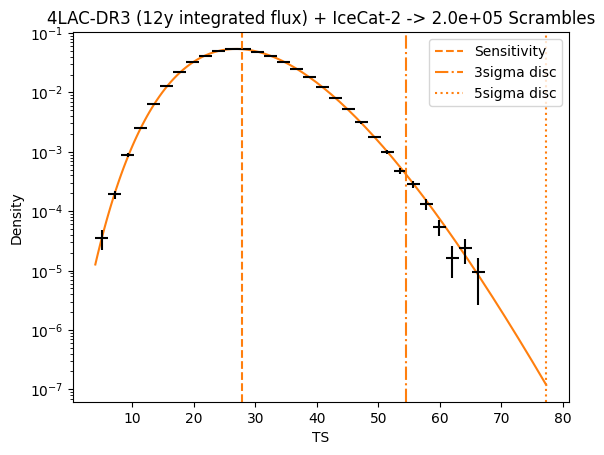

In [6]:
plot_ts(
    val,
    sens_threshold[key],
    disc_3_threshold[key],
    disc_5_threshold[key],
    gd,
    filename="attempt_plot.png"
)

#x = np.linspace(20,80,100)
#plt.plot(x, np.exp(-0.2*x))

plt.ylabel("Density")
plt.yscale("log")
plt.title(f"4LAC-DR3 (12y integrated flux) + IceCat-2 -> {len(val):.1e} Scrambles")
plt.savefig("4LACDR3_integrated_scrambles_updated_signalness", bbox_inches="tight", dpi=200)

In [7]:
levels = [
    ("Background Median", sens_threshold),
    ("3 Sigma Discovery Potential", disc_3_threshold),
    ("5 Sigma Discovery Potential", disc_5_threshold)
]

print(levels)

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in all_res.items():
    print("\nFraction of neutrino alerts correlated to source: {0} \n".format(step))

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val)

        for name, thresh in levels:
            print(thresh[key])
            print("Fraction above {0}: {1}".format(
                name, np.sum(val > thresh[key])/float(len(val))))
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]
sig3 = [list(above.values())[i][1] for i in range(len(fracs))]
sig5 = [list(above.values())[i][2] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')
f2 = interpolate.interp1d(fracs, sig3, kind='cubic')
f3 = interpolate.interp1d(fracs, sig5, kind='cubic')
print(f"\n\n\n*\t*\t*\t*\t*\t*\t*\n\nsens: {sens}\nsig3: {sig3}\nsig5: {sig5}\n\n*\t*\t*\t*\t*\t*\t*\n\n\n")

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in blazar_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0, 0.15, xtol=1e-6)
x2 = bisect(lambda x: f2(x)-0.5, 0, 0.15, xtol=1e-6)
x3 = bisect(lambda x: f3(x)-0.5, 0, 0.15, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("3 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x2,(x2*avg_signalness)*n_events,n_events,(x2*avg_signalness)))
print("5 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x3,(x3*avg_signalness)*n_events,n_events,(x3*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")

[('Background Median', {'average_flux_weight': np.float64(27.78091482536719)}), ('3 Sigma Discovery Potential', {'average_flux_weight': np.float64(54.426850868644806)}), ('5 Sigma Discovery Potential', {'average_flux_weight': np.float64(77.31108476816941)})]

Fraction of neutrino alerts correlated to source: 0.0 

27.78091482536719
Fraction above Background Median: 0.5
54.426850868644806
Fraction above 3 Sigma Discovery Potential: 0.00119
77.31108476816941
Fraction above 5 Sigma Discovery Potential: 0.0

Fraction of neutrino alerts correlated to source: 0.017499999999999998 

27.78091482536719
Fraction above Background Median: 0.8132
54.426850868644806
Fraction above 3 Sigma Discovery Potential: 0.03445
77.31108476816941
Fraction above 5 Sigma Discovery Potential: 0.00015

Fraction of neutrino alerts correlated to source: 0.034999999999999996 

27.78091482536719
Fraction above Background Median: 0.93945
54.426850868644806
Fraction above 3 Sigma Discovery Potential: 0.1738
77.3110847681

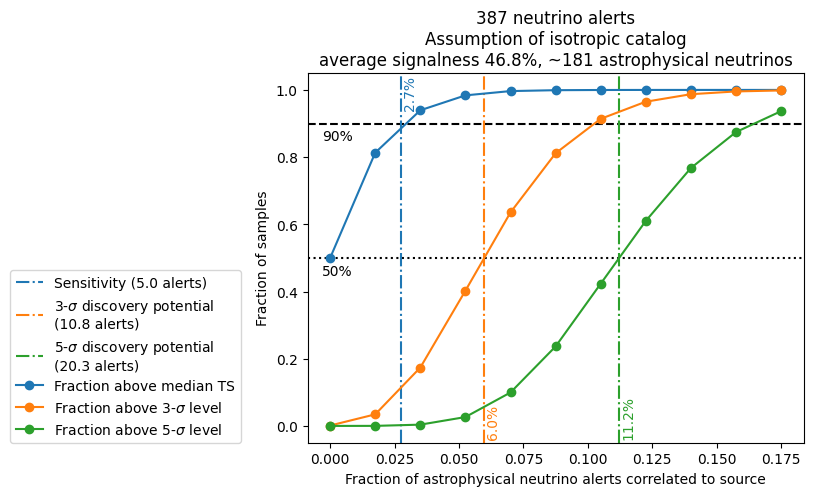

In [9]:
plt.axhline(0.5, color="black", linestyle="dotted")
plt.axhline(0.9, color="black", linestyle="dashed")

plt.axvline(
    x1,
    linestyle="dashdot",
    label=f"Sensitivity ({(x1*avg_signalness)*n_events:.1f} alerts)"
)
plt.axvline(
    x2,
    linestyle="dashdot",
    color="tab:orange",
    label=r"3-$\sigma$"
    f" discovery potential\n({(x2*avg_signalness)*n_events:.1f} alerts)"
)
plt.axvline(
    x3,
    linestyle="dashdot",
    color="tab:green",
    label=r"5-$\sigma$"
    f" discovery potential\n({(x3*avg_signalness)*n_events:.1f} alerts)"
)

plt.title(
    f"{n_events} neutrino alerts\nAssumption of isotropic catalog\n"
    f"average signalness {avg_signalness*100:.1f}%, "
    f"~{avg_signalness*n_events:.0f} astrophysical neutrinos"
)
plt.plot(fracs, sens, marker='o', label="Fraction above median TS")
plt.plot(fracs, sig3, marker='o', label=r"Fraction above 3-$\sigma$ level")
plt.plot(fracs, sig5, marker='o', label=r"Fraction above 5-$\sigma$ level")
plt.ylabel("Fraction of samples")
plt.xlabel("Fraction of astrophysical neutrino alerts correlated to source")

# plt.text(0.04, 0.55, "IceCube Preliminary", fontsize="x-large", color="red")

plt.text(x1 + 0.001, 0.95, f"{x1*100:.1f}%", color="tab:blue", rotation=90)
plt.text(x2 + 0.001, -0.03, f"{x2*100:.1f}%", color="tab:orange", rotation=90)
plt.text(x3 + 0.001, -0.03, f"{x3*100:.1f}%", color="tab:green", rotation=90)

plt.text(-0.003, 0.85, "90%", color="black")
plt.text(-0.003, 0.45, "50%", color="black")

plt.legend(loc=(-0.6, 0))
plt.savefig("4LACDR3_integrated_sens_updated_signalness", dpi=200, bbox_inches='tight')

In [15]:
# Load the latest results (search in ./cache) 
all_res = agn_analysis.load_results()

sens_threshold = dict()
disc_3_threshold = dict()
disc_5_threshold = dict()

zero_key = 0.0

# Calculate threshold for sensitivity and discovery potential by fitting the 
# background TS distribution (no correlation injected) to a gamma distribution
for key, val in all_res[zero_key].items():
    sens_threshold[key] = np.median(val)
    gd = GammaDistribution(val)
    disc_3_threshold[key] = gd.calculate_discovery_potential(3.)
    disc_5_threshold[key] = gd.calculate_discovery_potential(5.)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 678557.3784561851
        x: [ 4.134e+01 -1.454e+01  1.129e+00]
      nit: 65
      jac: [-2.631e+00 -3.155e+00  1.746e-01]
     nfev: 396
     njev: 99
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


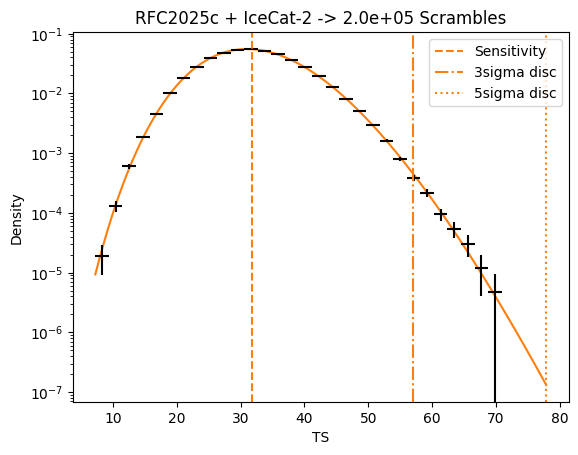

In [16]:
#from examples.radio_agn_neutrino_alert import plot_ts

plot_ts(
    val,
    sens_threshold[key],
    disc_3_threshold[key],
    disc_5_threshold[key],
    gd,
    filename="attempt_plot.png"
)

#x = np.linspace(20,80,100)
#plt.plot(x, np.exp(-0.2*x))

plt.ylabel("Density")
plt.yscale("log")
plt.title(f"RFC2025c + IceCat-2 -> {len(val):.1e} Scrambles")
plt.savefig("RFC2025c_scrambles_updated_signalness", bbox_inches="tight", dpi=200)

In [17]:
levels = [
    ("Background Median", sens_threshold),
    ("3 Sigma Discovery Potential", disc_3_threshold),
    ("5 Sigma Discovery Potential", disc_5_threshold)
]

print(levels)

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in all_res.items():
    print("\nFraction of neutrino alerts correlated to source: {0} \n".format(step))

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val)

        for name, thresh in levels:
            print(thresh[key])
            print("Fraction above {0}: {1}".format(
                name, np.sum(val > thresh[key])/float(len(val))))
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]
sig3 = [list(above.values())[i][1] for i in range(len(fracs))]
sig5 = [list(above.values())[i][2] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')
f2 = interpolate.interp1d(fracs, sig3, kind='cubic')
f3 = interpolate.interp1d(fracs, sig5, kind='cubic')
print(f"\n\n\n*\t*\t*\t*\t*\t*\t*\n\nsens: {sens}\nsig3: {sig3}\nsig5: {sig5}\n\n*\t*\t*\t*\t*\t*\t*\n\n\n")

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in agn_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0, 0.2, xtol=1e-6)
x2 = bisect(lambda x: f2(x)-0.5, 0, 0.2, xtol=1e-6)
x3 = bisect(lambda x: f3(x)-0.5, 0, 0.2, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("3 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x2,(x2*avg_signalness)*n_events,n_events,(x2*avg_signalness)))
print("5 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x3,(x3*avg_signalness)*n_events,n_events,(x3*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")

[('Background Median', {'average_radio_flux_weight': np.float64(31.801552319929264)}), ('3 Sigma Discovery Potential', {'average_radio_flux_weight': np.float64(56.956034203966)}), ('5 Sigma Discovery Potential', {'average_radio_flux_weight': np.float64(77.85674875156599)})]

Fraction of neutrino alerts correlated to source: 0.0 

31.801552319929264
Fraction above Background Median: 0.5
56.956034203966
Fraction above 3 Sigma Discovery Potential: 0.00122
77.85674875156599
Fraction above 5 Sigma Discovery Potential: 0.0

Fraction of neutrino alerts correlated to source: 0.02 

31.801552319929264
Fraction above Background Median: 0.7926
56.956034203966
Fraction above 3 Sigma Discovery Potential: 0.0257
77.85674875156599
Fraction above 5 Sigma Discovery Potential: 5e-05

Fraction of neutrino alerts correlated to source: 0.04 

31.801552319929264
Fraction above Background Median: 0.93045
56.956034203966
Fraction above 3 Sigma Discovery Potential: 0.12085
77.85674875156599
Fraction above 5 Si

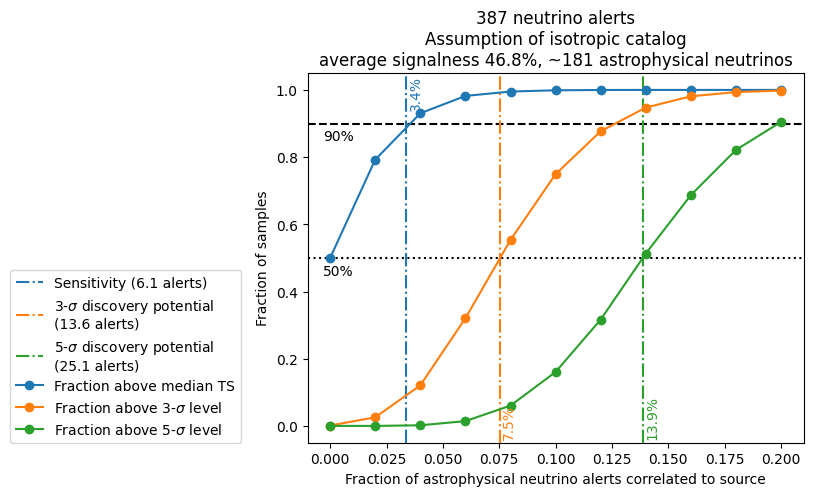

In [22]:
plt.axhline(0.5, color="black", linestyle="dotted")
plt.axhline(0.9, color="black", linestyle="dashed")

plt.axvline(
    x1,
    linestyle="dashdot",
    label=f"Sensitivity ({(x1*avg_signalness)*n_events:.1f} alerts)"
)
plt.axvline(
    x2,
    linestyle="dashdot",
    color="tab:orange",
    label=r"3-$\sigma$"
    f" discovery potential\n({(x2*avg_signalness)*n_events:.1f} alerts)"
)
plt.axvline(
    x3,
    linestyle="dashdot",
    color="tab:green",
    label=r"5-$\sigma$"
    f" discovery potential\n({(x3*avg_signalness)*n_events:.1f} alerts)"
)

plt.title(
    f"{n_events} neutrino alerts\nAssumption of isotropic catalog\n"
    f"average signalness {avg_signalness*100:.1f}%, "
    f"~{avg_signalness*n_events:.0f} astrophysical neutrinos"
)
plt.plot(fracs, sens, marker='o', label="Fraction above median TS")
plt.plot(fracs, sig3, marker='o', label=r"Fraction above 3-$\sigma$ level")
plt.plot(fracs, sig5, marker='o', label=r"Fraction above 5-$\sigma$ level")
plt.ylabel("Fraction of samples")
plt.xlabel("Fraction of astrophysical neutrino alerts correlated to source")

plt.legend(loc=(1.03, 0))

# plt.text(0.04, 0.55, "IceCube Preliminary", fontsize="x-large", color="red")

plt.text(x1 + 0.001, 0.95, f"{x1*100:.1f}%", color="tab:blue", rotation=90)
plt.text(x2 + 0.001, -0.03, f"{x2*100:.1f}%", color="tab:orange", rotation=90)
plt.text(x3 + 0.001, -0.03, f"{x3*100:.1f}%", color="tab:green", rotation=90)

plt.text(-0.003, 0.85, "90%", color="black")
plt.text(-0.003, 0.45, "50%", color="black")

plt.legend(loc=(-0.6, 0))
plt.savefig("RFC2025c_sens_updated_signalness", dpi=200, bbox_inches='tight')

In [23]:
from examples.fermi_LC_blazar_neutrino_alert import blazar_analysis

In [28]:
# Load the latest results (search in ./cache) 
all_res = blazar_analysis.load_results()

sens_threshold = dict()
disc_3_threshold = dict()
disc_5_threshold = dict()

zero_key = 0.0

# Calculate threshold for sensitivity and discovery potential by fitting the 
# background TS distribution (no correlation injected) to a gamma distribution
for key, val in all_res[zero_key].items():
    sens_threshold[key] = np.median(val)
    gd = GammaDistribution(val)
    disc_3_threshold[key] = gd.calculate_discovery_potential(3.)
    disc_5_threshold[key] = gd.calculate_discovery_potential(5.)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 683127.3482705989
        x: [ 2.267e+01 -1.148e+01  1.570e+00]
      nit: 47
      jac: [ 1.257e+00  9.546e-01  1.568e+01]
     nfev: 244
     njev: 61
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


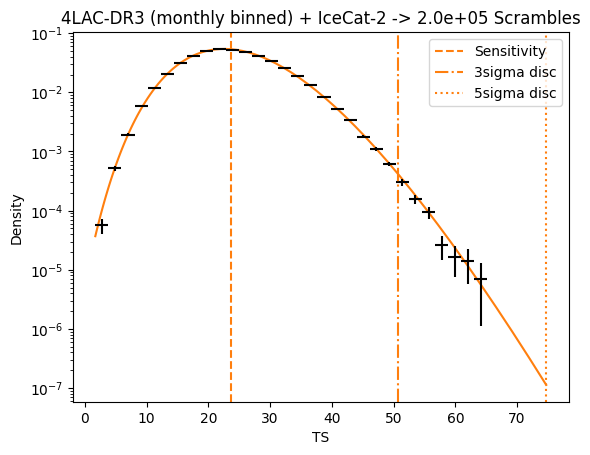

In [29]:
plot_ts(
    val,
    sens_threshold[key],
    disc_3_threshold[key],
    disc_5_threshold[key],
    gd,
    filename="attempt_plot.png"
)

#x = np.linspace(20,80,100)
#plt.plot(x, np.exp(-0.2*x))

plt.ylabel("Density")
plt.yscale("log")
plt.title(f"4LAC-DR3 (monthly binned) + IceCat-2 -> {len(val):.1e} Scrambles")
plt.savefig("4LACDR3_monthly_scrambles_updated_signalness", bbox_inches="tight", dpi=200)

In [30]:
levels = [
    ("Background Median", sens_threshold),
    ("3 Sigma Discovery Potential", disc_3_threshold),
    ("5 Sigma Discovery Potential", disc_5_threshold)
]

print(levels)

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in all_res.items():
    print("\nFraction of neutrino alerts correlated to source: {0} \n".format(step))

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val)

        for name, thresh in levels:
            print(thresh[key])
            print("Fraction above {0}: {1}".format(
                name, np.sum(val > thresh[key])/float(len(val))))
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]
sig3 = [list(above.values())[i][1] for i in range(len(fracs))]
sig5 = [list(above.values())[i][2] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')
f2 = interpolate.interp1d(fracs, sig3, kind='cubic')
f3 = interpolate.interp1d(fracs, sig5, kind='cubic')
print(f"\n\n\n*\t*\t*\t*\t*\t*\t*\n\nsens: {sens}\nsig3: {sig3}\nsig5: {sig5}\n\n*\t*\t*\t*\t*\t*\t*\n\n\n")

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in blazar_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0, 0.15, xtol=1e-6)
x2 = bisect(lambda x: f2(x)-0.5, 0, 0.15, xtol=1e-6)
x3 = bisect(lambda x: f3(x)-0.5, 0, 0.15, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("3 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x2,(x2*avg_signalness)*n_events,n_events,(x2*avg_signalness)))
print("5 Sigma discovery at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x3,(x3*avg_signalness)*n_events,n_events,(x3*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")

[('Background Median', {'monthly_flux_weight': np.float64(23.596095083374344)}), ('3 Sigma Discovery Potential', {'monthly_flux_weight': np.float64(50.75508791841188)}), ('5 Sigma Discovery Potential', {'monthly_flux_weight': np.float64(74.71708079119455)})]

Fraction of neutrino alerts correlated to source: 0.0 

23.596095083374344
Fraction above Background Median: 0.5
50.75508791841188
Fraction above 3 Sigma Discovery Potential: 0.00114
74.71708079119455
Fraction above 5 Sigma Discovery Potential: 0.0

Fraction of neutrino alerts correlated to source: 0.017499999999999998 

23.596095083374344
Fraction above Background Median: 0.85455
50.75508791841188
Fraction above 3 Sigma Discovery Potential: 0.05825
74.71708079119455
Fraction above 5 Sigma Discovery Potential: 0.00035

Fraction of neutrino alerts correlated to source: 0.034999999999999996 

23.596095083374344
Fraction above Background Median: 0.96895
50.75508791841188
Fraction above 3 Sigma Discovery Potential: 0.2801
74.717080791

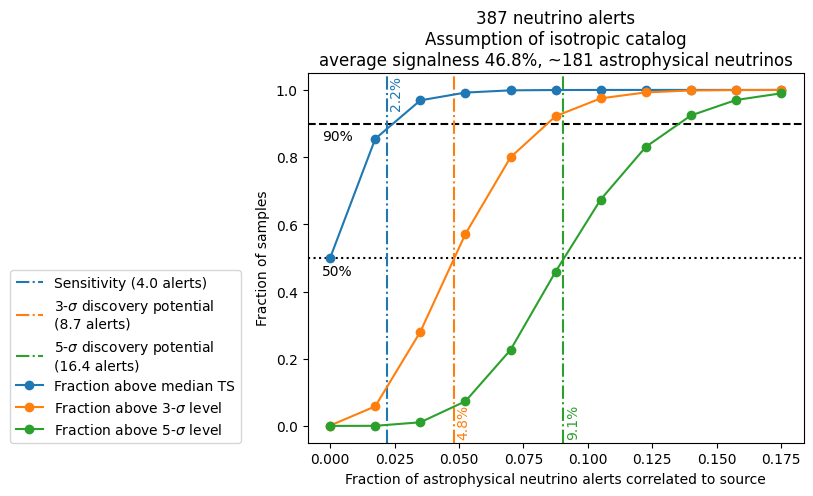

In [31]:
plt.axhline(0.5, color="black", linestyle="dotted")
plt.axhline(0.9, color="black", linestyle="dashed")

plt.axvline(
    x1,
    linestyle="dashdot",
    label=f"Sensitivity ({(x1*avg_signalness)*n_events:.1f} alerts)"
)
plt.axvline(
    x2,
    linestyle="dashdot",
    color="tab:orange",
    label=r"3-$\sigma$"
    f" discovery potential\n({(x2*avg_signalness)*n_events:.1f} alerts)"
)
plt.axvline(
    x3,
    linestyle="dashdot",
    color="tab:green",
    label=r"5-$\sigma$"
    f" discovery potential\n({(x3*avg_signalness)*n_events:.1f} alerts)"
)

plt.title(
    f"{n_events} neutrino alerts\nAssumption of isotropic catalog\n"
    f"average signalness {avg_signalness*100:.1f}%, "
    f"~{avg_signalness*n_events:.0f} astrophysical neutrinos"
)
plt.plot(fracs, sens, marker='o', label="Fraction above median TS")
plt.plot(fracs, sig3, marker='o', label=r"Fraction above 3-$\sigma$ level")
plt.plot(fracs, sig5, marker='o', label=r"Fraction above 5-$\sigma$ level")
plt.ylabel("Fraction of samples")
plt.xlabel("Fraction of astrophysical neutrino alerts correlated to source")

# plt.text(0.04, 0.55, "IceCube Preliminary", fontsize="x-large", color="red")

plt.text(x1 + 0.001, 0.95, f"{x1*100:.1f}%", color="tab:blue", rotation=90)
plt.text(x2 + 0.001, -0.03, f"{x2*100:.1f}%", color="tab:orange", rotation=90)
plt.text(x3 + 0.001, -0.03, f"{x3*100:.1f}%", color="tab:green", rotation=90)

plt.text(-0.003, 0.85, "90%", color="black")
plt.text(-0.003, 0.45, "50%", color="black")

plt.legend(loc=(-0.6, 0))
plt.savefig("4LACDR3_monthly_sens_updated_signalness", dpi=200, bbox_inches='tight')

## 